In [48]:
import pandas as pd
from typing import Any, Tuple

import numpy as np
from pykalman import KalmanFilter

In [3]:
# def add_gaussian_noise_to_signal(signal, mean=0, std=1):
#     noisy_signal = signal.copy()
#     noisy_signal['depth'] = noisy_signal['depth'] + np.random.normal(mean, std, len(noisy_signal['depth']))
#     return noisy_signal
# 
# df['noisy_signal'] = df['decrease'].apply(lambda x: add_gaussian_noise_to_signal(x, mean=0, std=0.1))  # Adjust `std` as needed

In [119]:
df

,deployment_id,label,inflection_t,signal,signal_padded,signal_sim,signal_sim_padded
uuid,,,,,,,
1690089,daily_happy_satyr,flood,6961,"{'time': [0, 567, 1009, 1639, 1765, 2080, 2395...","{'time': [0, 60, 120, 180, 240, 300, 867, 1309...","{'time': [0, 567, 1009, 1639, 1765, 2080, 2395...","{'time': [0, 60, 120, 180, 240, 300, 867, 1309..."
2578925,daily_happy_satyr,flood,7062,"{'time': [0, 1889, 1952, 2960, 4914, 4921, 674...","{'time': [0, 60, 120, 180, 240, 300, 2189, 225...","{'time': [0, 1889, 1952, 2960, 4914, 4921, 674...","{'time': [0, 60, 120, 180, 240, 300, 2189, 225..."
5301386,daily_happy_satyr,flood,5303,"{'time': [0, 1323, 1898, 1906, 2409, 2535, 278...","{'time': [0, 60, 120, 180, 240, 300, 1623, 219...","{'time': [0, 1323, 1898, 1906, 2409, 2535, 278...","{'time': [0, 60, 120, 180, 240, 300, 1623, 219..."
2808962,daily_happy_satyr,flood,4789,"{'time': [126, 441, 503, 566, 882, 1008, 1071,...","{'time': [0, 60, 120, 180, 240, 300, 615, 677,...","{'time': [126, 441, 503, 566, 882, 1008, 1071,...","{'time': [0, 60, 120, 180, 240, 300, 615, 677,..."
9041605,daily_happy_satyr,flood,6188,"{'time': [0, 379, 1449, 1575, 1890, 2394, 2709...","{'time': [0, 60, 120, 180, 240, 300, 679, 1749...","{'time': [0, 379, 1449, 1575, 1890, 2394, 2709...","{'time': [0, 60, 120, 180, 240, 300, 679, 1749..."
...,...,...,...,...,...,...,...
8759904,daily_happy_satyr,flood,1825,"{'time': [0, 63, 251, 376, 439, 628, 755, 817,...","{'time': [0, 60, 120, 180, 240, 300, 363, 551,...","{'time': [0, 63, 251, 376, 439, 628, 755, 817,...","{'time': [0, 60, 120, 180, 240, 300, 363, 551,..."
2143905,daily_happy_satyr,flood,3232,"{'time': [0, 315, 504, 756, 2019, 2216, 3232, ...","{'time': [0, 60, 120, 180, 240, 300, 615, 804,...","{'time': [0, 315, 504, 756, 2019, 2216, 3232, ...","{'time': [0, 60, 120, 180, 240, 300, 615, 804,..."
9920921,daily_happy_satyr,flood,2840,"{'time': [0, 377, 566, 756, 1071, 1449, 1763, ...","{'time': [0, 60, 120, 180, 240, 300, 677, 866,...","{'time': [0, 377, 566, 756, 1071, 1449, 1763, ...","{'time': [0, 60, 120, 180, 240, 300, 677, 866,..."


In [112]:
df = pd.read_pickle("flood_df")
df.head()
df.iloc[3]["signal"]

{'time': array([ 126,  441,  503,  566,  882, 1008, 1071, 1954, 2018, 2143, 2583,
        2898, 3087, 3403, 3592, 3718, 3781, 4097, 4411, 4536, 4789, 5292,
        5796, 5986, 6174, 6237, 6363, 6488, 6496, 6623, 7314, 7565, 7629,
        8384, 8700, 8889]),
 'depth': array([ 20.,  28.,  30.,  33.,  43.,  52.,  51.,  88.,  93.,  98., 118.,
        126., 132., 140., 142., 141., 145., 151., 153., 154., 156., 158.,
        149., 145., 139., 137., 136., 132., 132., 126., 101.,  89.,  85.,
         43.,  20.,   3.])}

In [6]:
def preprocess_signal(signal):
    time = signal['time']
    depth = signal['depth']
    return pd.DataFrame({'time': time, 'depth': depth}).sort_values(by='time')

df['processed_signal'] = df['signal_padded'].apply(preprocess_signal)
print(df['processed_signal'].iloc[0])

     time  depth
0       0    0.0
1      60    0.0
2     120    0.0
3     180    0.0
4     240    0.0
5     300    4.0
6     867   18.0
7    1309   25.0
8    1939   35.0
9    2065   37.0
10   2380   50.0
11   2695   64.0
12   2947   79.0
13   3010   82.0
14   3136   90.0
15   3387  110.0
16   3766  139.0
17   4018  160.0
18   4080  164.0
19   4332  181.0
20   5215  237.0
21   5781  266.0
22   6033  274.0
23   6229  283.0
24   6489  292.0
25   6560  296.0
26   6568  296.0
27   6694  298.0
28   6757  298.0
29   6820  300.0
30   7198  307.0
31   7261  308.0
32   7386  310.0
33   7575  307.0
34   7638  302.0
35   8142  297.0
36   8269  292.0
37   9088  268.0
38   9151  266.0
39   9403  260.0
40  10033  240.0
41  10536  220.0
42  10915  204.0
43  11230  189.0
44  11734  162.0
45  12238  131.0
46  12868   85.0
47  12993   74.0
48  13182   59.0
49  13497   34.0
50  13560   24.0
51  13812    2.0
52  13872    0.0
53  13932    0.0
54  13992    0.0
55  14052    0.0
56  14112    0.0


In [8]:
def vectorized_kalman_filter_3d(signal):
    observations = signal['depth'].values
    times = signal['time'].values
    time_diffs = np.diff(times, prepend=times[0])  # Compute time gaps with 0 for the first element

    # Initialize state and covariance matrices
    n_observations = len(observations)
    state_dim = 3  # [depth, velocity, acceleration]
    filtered_means = np.zeros((n_observations, state_dim))
    smoothed_means = np.zeros((n_observations, state_dim))
    covariances = np.zeros((n_observations, state_dim, state_dim))

    # Initial state and covariance
    state_mean = np.array([observations[0], 0, 0])  # Initial [depth, velocity, acceleration]
    state_covariance = np.eye(state_dim) * 1  # Initial uncertainty
    observation_matrix = np.array([[1, 0, 0]])  # Observation model
    observation_covariance = np.array([[10]])  # Observation noise
    process_noise_base = np.array([[6, 0.05, 0.0], [6, 0.1, 0.0], [0.0, 0.0, 0.0]]) / 10

    epsilon = 1e-6  # Small value for regularization

    # Filtering
    for t in range(n_observations):
        if t > 0:
            delta_t = time_diffs[t - 1]
            transition_matrix = np.array([
                [1, delta_t, 0.5 * delta_t**2],
                [0, 1, delta_t],
                [0, 0, 1]
            ])
            process_noise = process_noise_base * delta_t

            # Predict step
            predicted_state_mean = np.dot(transition_matrix, state_mean)
            predicted_state_cov = (
                np.dot(transition_matrix, np.dot(state_covariance, transition_matrix.T)) + process_noise
            )

            # Update step
            innovation = observations[t] - np.dot(observation_matrix, predicted_state_mean)
            innovation_cov = (
                np.dot(observation_matrix, np.dot(predicted_state_cov, observation_matrix.T))
                + observation_covariance
            )
            kalman_gain = np.dot(
                predicted_state_cov,
                np.dot(observation_matrix.T, np.linalg.inv(innovation_cov + epsilon * np.eye(innovation_cov.shape[0])))
            )
            state_mean = predicted_state_mean + np.dot(kalman_gain, innovation)
            state_covariance = predicted_state_cov - np.dot(
                kalman_gain, np.dot(observation_matrix, predicted_state_cov)
            )

        # Store filtered results
        filtered_means[t] = state_mean
        covariances[t] = state_covariance

    # Smoothing
    smoothed_means[-1] = filtered_means[-1]
    smoothed_covariance = covariances[-1]
    for t in range(n_observations - 2, -1, -1):
        delta_t = time_diffs[t]
        transition_matrix = np.array([
            [1, delta_t, 0.5 * delta_t**2],
            [0, 1, delta_t],
            [0, 0, 1]
        ])

        # RTS smoother gain
        predicted_covariance = (
            np.dot(transition_matrix, np.dot(covariances[t], transition_matrix.T)) + process_noise_base * delta_t
        )
        predicted_covariance += epsilon * np.eye(predicted_covariance.shape[0])  # Regularization
        smoother_gain = np.dot(
            covariances[t],
            np.dot(transition_matrix.T, np.linalg.pinv(predicted_covariance))  # Use pseudo-inverse
        )

        # Update smoothed state
        smoothed_means[t] = (
            filtered_means[t]
            + np.dot(smoother_gain, (smoothed_means[t + 1] - np.dot(transition_matrix, filtered_means[t])))
        )

    # Add filtered and smoothed results to the signal DataFrame
    signal['kalman_depth'] = filtered_means[:, 0]
    signal['smoothed_depth'] = smoothed_means[:, 0]
    signal['velocity'] = filtered_means[:, 1]
    signal['acceleration'] = filtered_means[:, 2]
    return signal


In [9]:
df['filtered_signal'] = df['processed_signal'].apply(vectorized_kalman_filter_3d)

In [10]:
print(df['filtered_signal'].iloc[4])

     time  depth  kalman_depth  smoothed_depth   velocity  acceleration
0       0    0.0      0.000000        0.000389   0.000000      0.000000
1      60    0.0      0.000000        0.000389   0.000000      0.000000
2     120    0.0      0.000000       -0.058623   0.000000      0.000000
3     180    0.0      0.000000        0.126052   0.000000      0.000000
4     240    0.0      0.000000       -0.002089   0.000000      0.000000
5     300   10.0     10.040258        9.973199   0.031942      0.000166
6     679   17.0     17.024045       17.036147   0.036878      0.000146
7    1749   44.0     44.000077       43.984448   0.097238      0.000147
8    1875   49.0     49.001301       49.010349  -0.001640      0.000144
9    2190   61.0     60.999362       60.987734   0.109108      0.000144
10   2694   81.0     81.003337       81.003187   0.023206      0.000143
11   3009   98.0     98.000196       97.997376   0.063778      0.000143
12   3072  101.0    101.000549      102.048964   0.021609      0

In [11]:
def em_for_kalman_with_obs_update(signal_set, max_iterations=50, tolerance=1e-4):
    state_dim = 3
    observation_dim = 1

    # Initial guesses for parameters
    global_transition_matrix = np.array([
        [1, 1, 0.5],
        [0, 1, 1],
        [0, 0, 1]
    ])
    global_observation_matrix = np.array([[1, 0, 0]])
    global_process_noise_cov = np.array([[6, 0.05, 0.0], [6, 0.1, 0.0], [0.0, 0.0, 0.0]]) / 10
    global_observation_noise_cov = np.array([[10]])

    for iteration in range(max_iterations):
        # Initialize accumulators for sufficient statistics
        S_xx = np.zeros((state_dim, state_dim))
        S_x_prev_x = np.zeros((state_dim, state_dim))
        S_obs_obs = 0
        S_obs_state = np.zeros((observation_dim, state_dim))
        count_transitions = 0

        # E-Step: Run Kalman filtering and smoothing for each flood event
        for signal in signal_set:
            observations = signal['depth'].values
            times = signal['time'].values
            time_diffs = np.diff(times, prepend=times[0])

            # Apply Kalman filter and smoother
            signal = vectorized_kalman_filter_3d(signal)

            # Collect sufficient statistics
            smoothed_means = signal[['kalman_depth', 'velocity', 'acceleration']].values

            for t in range(1, len(observations)):
                x_t = smoothed_means[t]
                x_t_prev = smoothed_means[t - 1]
                y_t = observations[t]

                # Update transition-related statistics
                S_xx += np.outer(x_t, x_t)
                S_x_prev_x += np.outer(x_t_prev, x_t)
                count_transitions += 1

                # Update observation-related statistics
                S_obs_obs += y_t**2
                S_obs_state += np.outer(y_t, x_t)

        # M-Step: Update global parameters
        global_transition_matrix = S_x_prev_x / count_transitions
        global_process_noise_cov = (S_xx - np.dot(S_x_prev_x.T, global_transition_matrix)) / count_transitions

        # Update observation parameters
        global_observation_matrix = np.dot(S_obs_state, np.linalg.inv(S_xx))
        global_observation_noise_cov = (S_obs_obs - np.trace(np.dot(S_obs_state, global_observation_matrix.T))) / len(observations)

        # Check for convergence
        if np.linalg.norm(global_process_noise_cov - np.eye(state_dim)) < tolerance:
            break

    # Store the learned parameters
    global_params = {
        'transition_matrix': global_transition_matrix,
        'process_noise_cov': global_process_noise_cov,
        'observation_matrix': global_observation_matrix,
        'observation_noise_cov': global_observation_noise_cov
    }
    return global_params


In [12]:
filtered_signals = df['filtered_signal'].tolist()
global_params = em_for_kalman_with_obs_update(filtered_signals)

In [13]:
print(global_params)

{'transition_matrix': array([[ 1.17563900e+14, -1.11966241e+14,  1.77095343e+01],
       [-5.19372503e+14, -4.85843235e+14, -5.27231883e+01],
       [ 1.79690848e+01, -5.36376267e+01,  1.44211716e-06]]), 'process_noise_cov': array([[-2.83569068e+29, -2.39170429e+29, -2.94649762e+16],
       [-2.39170429e+29, -2.48580088e+29, -2.36323344e+16],
       [-2.94649762e+16, -2.36323344e+16, -3.09336219e+03]]), 'observation_matrix': array([[ 5.27833605e-10, -5.96391761e-11,  9.03406982e+03]]), 'observation_noise_cov': 168207042.57300618}


In [84]:
global_params = pd.read_pickle("global_params.pkl")

In [86]:
global_params = pd.read_pickle("global_params.pkl")
transition_matrix = global_params["transition_matrix"]
process_noise_cov = global_params["process_noise_cov"] 
observation_matrix = global_params["observation_matrix"]
observation_noise_cov = global_params["observation_noise_cov"]

In [87]:
class KalmanFilter:
    """Class that implements the Kalman Filter for our LDS model.

    Args:
        sigma_w: Standard deviation of latent space noise.
        sigma_v: Standard deviation of observation noise.
        a: Magnitude of latent space transition matrix.
        c: Magnitude of the observation matrix.
        dim_z: Dimension of latent space.
        dim_x: Dimension of observation space.
        sigma_w_zero: Initial standard deviation of the zero state.
        mu_zero: Initial mean of the zero state.
    """
    def __init__(self, transition_matrix:np.ndarray, transition_covariance:np.ndarray, observation_matrix:np.ndarray, observation_covariance:np.ndarray, dim_z: int, 
                 dim_x: int, cov_zero: np.ndarray, mu_zero: np.ndarray):
        """Initialize our class."""
        # Save a few variables for bookkeeping
        self.dim_x = dim_x
        self.dim_z = dim_z

        # Used in the EM function.
        self.smooth_matrices = None # The F_t matrices from the notes. Will need to be saved.
        
        # TODO: Implement the transition, observation, and noise covariance matrices.
        self.transition_covariance = transition_covariance
        self.observation_covariance = observation_covariance
        self.transition_matrix = transition_matrix
        self.observation_matrix = observation_matrix

        # TODO: Implement the initial covariance and mean of the zero state.
        self.mu_zero = mu_zero
        self.cov_zero = cov_zero
        
    def filter(self, data: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
        """Calculate the filtered mean and covariances of the latent space.

        Args:
            data: Observations with shape [n_observations, dim_x]

        Returns:
            Filtered mean and covariance for the latent space. The first dimension
            of both should by n_observations+1 since the initial latent state has no
            paired observation.
        """
        # Make sure the dimensions match and create some placeholders for the outputs.
       
        n_observations, dim_x = data.shape
        assert dim_x == self.dim_x
        filtered_means = np.zeros((n_observations + 1, self.dim_z))
        filtered_covs = np.zeros((n_observations + 1, self.dim_z, self.dim_z))
        
        # TODO: Implement filtering.
        #implement predictions 
        A = self.transition_matrix
        C = self.observation_matrix

        Q = self.transition_covariance 
        R = self.observation_covariance

        #predict
        self.z = self.mu_zero
        self.P = self.cov_zero
        
        def predict(self, A, Q):
            self.z = np.dot(A, self.z) 
            self.P = np.dot(np.dot(A, self.P), A.T) + Q
            return self.z, self.P

        def update(self, x, C, R):
            y = x - np.dot(C, self.z)
            S = R + np.dot(C, np.dot(self.P, C.T))
            K = np.dot(np.dot(self.P, C.T), np.linalg.inv(S))
            self.z = self.z + np.dot(K, y)
            I = np.eye(self.dim_z)
            self.P = np.dot(np.dot(I - np.dot(K, C), self.P), (I - np.dot(K, C)).T) + np.dot(np.dot(K, R), K.T)
            return self.z, self.P

          
        filtered_covs[0,:] = self.cov_zero
        filtered_means[0,:] = self.mu_zero
        
        for i in range(n_observations):
            x = data[i,:]
            z,P = predict(self, A, Q) 
     		
            z_upd, P_upd = update(self, x,C, R)
            filtered_means[i+1,:] = z_upd
            filtered_covs[i+1,:] = P_upd

        return filtered_means, filtered_covs

    def smooth(self, data: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
        """Calculate the smoothed mean and covariances of the latent space.

        Args:
            data: Observations with shape [n_observations, dim_x]

        Returns:
            Smoothed mean and covariance for the latent space. The first dimension
            of both should by n_observations+1 since the initial latent state has no
            paired observation.

        Notes:
            
        """
        # Validate the data dimensions.
        n_observations, dim_x = data.shape
        assert dim_x == self.dim_x
        
        A = self.transition_matrix
        C = self.observation_matrix

        Q = self.transition_covariance 
        R = self.observation_covariance
        # Run the forward path
        filtered_means, filtered_covs = self.filter(data)
      # Create holders for outputs
        smoothed_means = np.zeros((n_observations + 1, self.dim_z))
        smoothed_covs = np.zeros((n_observations + 1, self.dim_z, self.dim_z))
        smooth_matrices = np.zeros((n_observations + 1, self.dim_z, self.dim_z))
        
        smoothed_means[-1] = filtered_means[-1]
        smoothed_covs[-1] = filtered_covs[-1]
        smooth_matrices[-1] = np.eye(self.dim_z)
        
        # TODO: Implement smoothing.
        for t in range(n_observations - 1, -1, -1):
            mu_pred = A @ filtered_means[t]
            P_pred = A @ filtered_covs[t] @ A.T + Q
            F = filtered_covs[t] @ A.T @ np.linalg.inv(P_pred)
            
            smoothed_means[t] = filtered_means[t] + F @ (smoothed_means[t + 1] - mu_pred)
            smoothed_covs[t] = filtered_covs[t] + F @ (smoothed_covs[t + 1] - P_pred) @ F.T
            smooth_matrices[t] = F
        self.smooth_matrices = smooth_matrices

        return smoothed_means, smoothed_covs  


In [88]:
kf = KalmanFilter(transition_matrix, process_noise_cov, observation_matrix, observation_noise_cov, dim_z = 3, 
                 dim_x = 1, cov_zero = np.array([10, 0, 0]),  mu_zero = np.array([0, 0, 0]))
filtered_means, filtered_covs = kf.filter(np.array(measurements["depth"].values).reshape(-1,1))
smoothed_means, smoothed_covs = kf.smooth(np.array(measurements["depth"].values).reshape(-1,1))

In [91]:
filtered_observations = filtered_means @ observation_matrix.T
smoothed_observations = smoothed_means @ observation_matrix.T

In [115]:
filtered_means[:,0]

array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 3.99999580e+00, 1.79999820e+01,
       2.49999764e+01, 3.49999690e+01, 3.69999715e+01, 4.99999629e+01,
       6.39999546e+01, 7.89999467e+01, 8.19999541e+01, 8.99999558e+01,
       1.09999944e+02, 1.38999924e+02, 1.59999916e+02, 1.63999929e+02,
       1.80999927e+02, 2.36999881e+02, 2.65999872e+02, 2.73999890e+02,
       2.82999907e+02, 2.91999921e+02, 2.95999939e+02, 2.95999959e+02,
       2.97999972e+02, 2.97999984e+02, 2.99999991e+02, 3.06999989e+02,
       3.07999993e+02, 3.09999995e+02, 3.07000001e+02, 3.02000008e+02,
       2.97000013e+02, 2.92000017e+02, 2.68000041e+02, 2.66000037e+02,
       2.60000036e+02, 2.40000050e+02, 2.20000062e+02, 2.04000067e+02,
       1.89000069e+02, 1.62000084e+02, 1.31000100e+02, 8.50001305e+01,
       7.40001156e+01, 5.90001051e+01, 3.40001066e+01, 2.40000905e+01,
       2.00009009e+00, 6.74426964e-05, 4.59053026e-05, 2.83476983e-05,
      

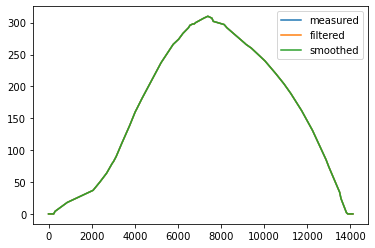

In [116]:
from matplotlib import pyplot as plt

plt.plot(measurements.time, measurements.depth, label="measured") 
plt.plot(measurements.time, filtered_means[1:,0], label="filtered") 
plt.plot(measurements.time, smoothed_means[1:,0], label="smoothed") 
plt.legend()